In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('C:\\Users\\sivap\\OneDrive\\Desktop\\Jupiter note bok\\Iphone Sales Data set.csv')
df.head()


,iPhone_Model_Name,Date,Country,Region,Units_Sold,Revenue_USD,Average_Selling_Price,Market_Share_%,Growth_Rate_%,Google_Search_Index,...,Conversion_Rate_%,Storage_Variant,Color,Discount_%,Sales_Channel,Holiday_Season,Inflation_Rate,Preorders_Count,Return_Rate_%,Year
0,iPhone 14 Pro,25-01-2026,India,Asia,136958,109429442,799,38.90,-3.23,57,...,3.20,128GB,Gold,3.90,Online,No,1.88,47131,1.57,2026
1,iPhone 17,22-06-2025,Brazil,South America,56090,67251910,1199,15.62,17.22,93,...,2.50,512GB,Gold,24.81,Retail Store,Yes,5.51,88305,3.10,2025
2,iPhone 16,29-10-2025,Canada,North America,145608,160023192,1099,30.74,2.40,77,...,3.55,256GB,Black,2.27,Online,Yes,5.52,70435,3.06,2025
3,iPhone 16,25-01-2024,UK,Europe,46551,46504449,999,29.00,14.36,56,...,2.79,128GB,Titanium,23.72,Carrier,Yes,7.78,76969,2.54,2024
4,iPhone 15 Pro,09-03-2024,UAE,Middle East,169969,169799031,999,17.93,9.79,96,...,5.24,1TB,Blue,20.83,Retail Store,Yes,2.63,38920,2.04,2024


In [10]:
df.shape

(3000, 22)

In [11]:
df.columns

Index(['iPhone_Model_Name', 'Date', 'Country', 'Region', 'Units_Sold',
       'Revenue_USD', 'Average_Selling_Price', 'Market_Share_%',
       'Growth_Rate_%', 'Google_Search_Index', 'Social_Media_Mentions',
       'Ad_Spend_USD', 'Conversion_Rate_%', 'Storage_Variant', 'Color',
       'Discount_%', 'Sales_Channel', 'Holiday_Season', 'Inflation_Rate',
       'Preorders_Count', 'Return_Rate_%', 'Year'],
      dtype='str')

In [12]:
df.isnull().sum()

iPhone_Model_Name        0
Date                     0
Country                  0
Region                   0
Units_Sold               0
Revenue_USD              0
Average_Selling_Price    0
Market_Share_%           0
Growth_Rate_%            0
Google_Search_Index      0
Social_Media_Mentions    0
Ad_Spend_USD             0
Conversion_Rate_%        0
Storage_Variant          0
Color                    0
Discount_%               0
Sales_Channel            0
Holiday_Season           0
Inflation_Rate           0
Preorders_Count          0
Return_Rate_%            0
Year                     0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# finding regional sales
regional_sales = df.groupby('Region')['Units_Sold'].sum()
print(regional_sales)

Region
Asia             58888324
Europe           84016850
Middle East      28161475
North America    55367344
Oceania          33615204
South America    29403529
Name: Units_Sold, dtype: int64


In [3]:
# finding highest sales region
highest_sales_region = df.groupby('Region')['Units_Sold'].sum().idxmax()
print(highest_sales_region)

Europe


In [17]:
# finding indian sales
indian_sales = df[df['Country'] == 'India']['Units_Sold'].sum()
print(indian_sales)

32491422


In [18]:
# finding highest sales country
highest_sales_country = df.groupby('Country')['Units_Sold'].sum().idxmax()  
print(highest_sales_country)

Australia


In [20]:
# finding google search index in india
google_search_index_india = df[df['Country'] == 'India']['Google_Search_Index'].mean()
print(google_search_index_india)

75.15644171779141


In [21]:
# finding google search index in all countries
google_search_index_all = df.groupby('Country')['Google_Search_Index'].mean()   
print(google_search_index_all)

Country
Australia    74.082278
Brazil       74.273333
Canada       74.194079
France       75.369637
Germany      73.699324
India        75.156442
Japan        74.924460
UAE          73.910653
UK           73.674419
USA          74.828070
Name: Google_Search_Index, dtype: float64


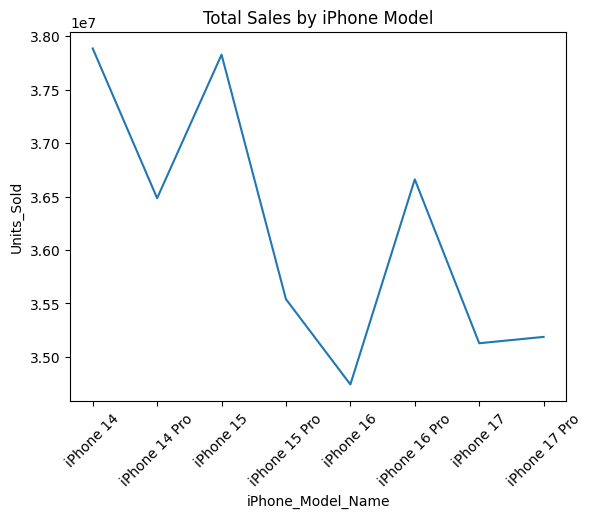

In [39]:
model_sales = df.groupby("iPhone_Model_Name")["Units_Sold"].sum().reset_index()

plt.figure()
sns.lineplot(data=model_sales, x="iPhone_Model_Name", y="Units_Sold")
plt.title("Total Sales by iPhone Model")
plt.xticks(rotation=45)
plt.show()

In [41]:
df.columns

Index(['iPhone_Model_Name', 'Date', 'Country', 'Region', 'Units_Sold',
       'Revenue_USD', 'Average_Selling_Price', 'Market_Share_%',
       'Growth_Rate_%', 'Google_Search_Index', 'Social_Media_Mentions',
       'Ad_Spend_USD', 'Conversion_Rate_%', 'Storage_Variant', 'Color',
       'Discount_%', 'Sales_Channel', 'Holiday_Season', 'Inflation_Rate',
       'Preorders_Count', 'Return_Rate_%', 'Year'],
      dtype='str')

In [46]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])


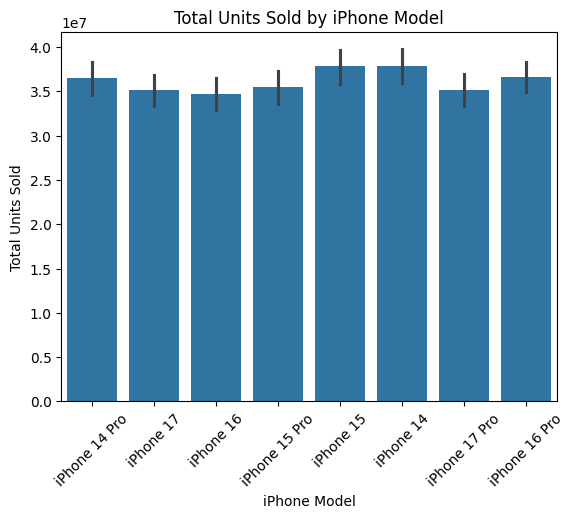

In [47]:
plt.figure()
sns.barplot(data=df, x='iPhone_Model_Name', y='Units_Sold', estimator=sum)
plt.xticks(rotation=45)
plt.title("Total Units Sold by iPhone Model")
plt.xlabel("iPhone Model")
plt.ylabel("Total Units Sold")
plt.show()

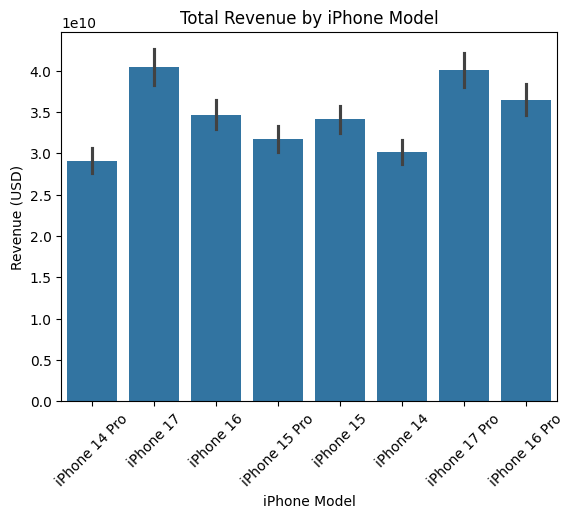

In [49]:
plt.figure()
sns.barplot(data=df, x='iPhone_Model_Name', y='Revenue_USD', estimator=sum)
plt.xticks(rotation=45)
plt.title("Total Revenue by iPhone Model")
plt.xlabel("iPhone Model")
plt.ylabel("Revenue (USD)")
plt.show()

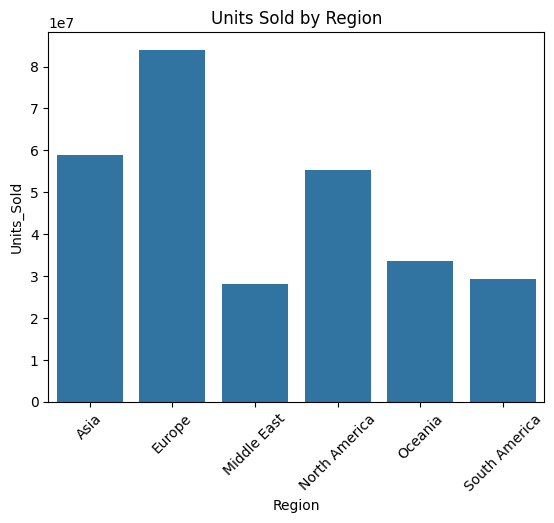

In [64]:
region_sales = df.groupby('Region')['Units_Sold'].sum().reset_index()

plt.figure()
sns.barplot(data=region_sales, x='Region', y='Units_Sold')
plt.title("Units Sold by Region")
plt.xticks(rotation=45)
plt.show()


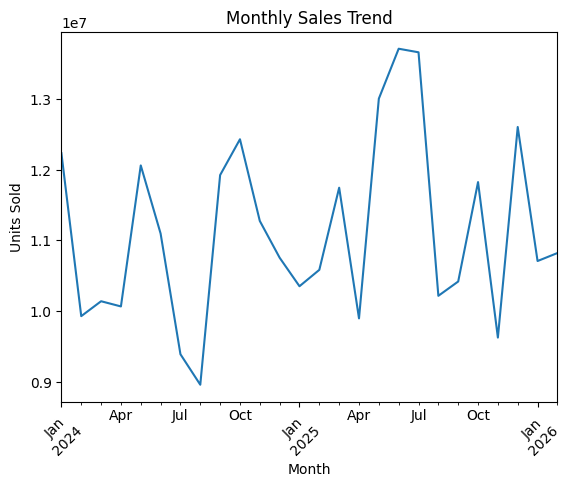

In [51]:
monthly_sales = df.groupby(df['Date'].dt.to_period("M"))['Units_Sold'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

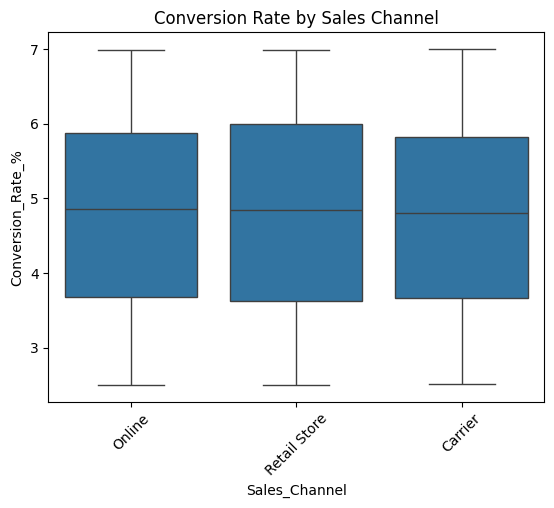

In [68]:
plt.figure()
sns.boxplot(data=df, x='Sales_Channel', y='Conversion_Rate_%')
plt.xticks(rotation=45)
plt.title("Conversion Rate by Sales Channel")
plt.show()

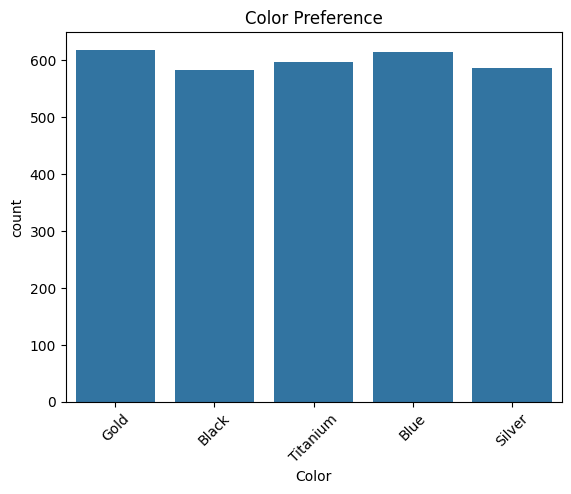

In [69]:
plt.figure()
sns.countplot(data=df, x='Color')
plt.xticks(rotation=45)
plt.title("Color Preference")
plt.show()